# Домашнее задание - 2

**Выполнила:** Салман Ясмина

id: 90

- Year: 2022

- Industry: все

- Region: 
Алтайский край, Бийск и Бийский район

In [1]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import skew, kurtosis
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt

import dataframe_image as dfi

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_hw = pd.read_csv('Homework_2_data.csv', sep=';')
df_hw.head()

,region,educ,age,female,industry,work_hours,wage,foreign_language,internet,alcohol,is_children,health,weight,height,smoke,year
0,"Ленинградская область, Волосовский район",0,"68,5",1,ЗДРАВООХРАНЕНИЕ,24,25000,0,1,0,1,0,78,164,0,2023
1,"Ленинградская область, Волосовский район",0,"69,5",0,"АРМИЯ, МВД, ОРГАНЫ БЕЗОПАСНОСТИ",24,35000,0,0,1,1,0,81,176,0,2023
2,"Ленинградская область, Волосовский район",0,"42,5",1,ЗДРАВООХРАНЕНИЕ,24,60000,0,1,1,1,0,98,161,1,2023
3,"Ленинградская область, Волосовский район",2,"47,5",1,ОБРАЗОВАНИЕ,8,95000,1,1,1,1,0,83,163,0,2023
4,"Ленинградская область, Волосовский район",0,60,1,ЖИЛИЩНО-КОММУНАЛЬНОЕ ХОЗЯЙСТВО,24,29000,0,1,1,1,1,100,163,0,2023


In [3]:
year = 2022
industry = ''
region = 'Алтайский край, Бийск и Бийский район'

df = df_hw[(df_hw['region'] == region) & (df_hw['year'] == year)]
df

,region,educ,age,female,industry,work_hours,wage,foreign_language,internet,alcohol,is_children,health,weight,height,smoke,year
4977,"Алтайский край, Бийск и Бийский район",2,39,1,ОБРАЗОВАНИЕ,8,18000,0,1,1,1,0,65,167,0,2022
4978,"Алтайский край, Бийск и Бийский район",2,55,1,"ТОРГОВЛЯ, БЫТОВОЕ ОБСЛУЖИВАНИЕ",9,15000,0,1,1,1,0,89,175,0,2022
4979,"Алтайский край, Бийск и Бийский район",0,57,1,"ТОРГОВЛЯ, БЫТОВОЕ ОБСЛУЖИВАНИЕ",14,16000,0,1,1,1,1,75,163,1,2022
4980,"Алтайский край, Бийск и Бийский район",2,54,0,ДРУГАЯ ОТРАСЛЬ ТЯЖЕЛОЙ ПРОМЫШЛЕННОСТИ,8,2000,1,1,0,1,0,69,177,0,2022
4981,"Алтайский край, Бийск и Бийский район",0,38,1,"ЛЕГКАЯ, ПИЩЕВАЯ ПРОМЫШЛЕННОСТЬ",8,20000,0,1,1,1,0,80,168,0,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10395,"Алтайский край, Бийск и Бийский район",0,40,1,"ТРАНСПОРТ, СВЯЗЬ",12,30000,0,1,1,1,1,62,162,1,2022
10396,"Алтайский край, Бийск и Бийский район",1,23,0,НЕФТЕГАЗОВАЯ ПРОМЫШЛЕННОСТЬ,12,40000,0,1,1,0,0,59,161,0,2022
10397,"Алтайский край, Бийск и Бийский район",1,22,1,"ТОРГОВЛЯ, БЫТОВОЕ ОБСЛУЖИВАНИЕ",12,30000,0,1,1,0,0,51,159,0,2022
10398,"Алтайский край, Бийск и Бийский район",1,51,1,ВОЕННО-ПРОМЫШЛЕННЫЙ КОМПЛЕКС,8,30000,0,1,1,1,0,81,169,1,2022


## 1.

**Опишите Вашу выборку. Что является в Вашем случае генеральной совокупностью? Как можно проверить репрезентативность Вашей выборки? (описать
словами, не проверять)**.

В выборке - 107 наблюдений. Генеральная совокупность - наблюдения по всем жителям данного региона в указанный год. Для того, чтобы утверждать, что выборка репрезентативная нужно убедиться, что она собрана случайным образом (все объекты генеральной совокупности имели равную вероятность попасть в выборку). Главное, чтобы выборка отражала основные свойства генеральной совокупности: соотношение классов, распределений и прч. Для того, чтобы это проверить, в целом, вполне возмонжно сравнить данные по всему региону с данной (весьма небольшой выборкой) и с помощью теста Колмогорова проверить распределение выборки (совпадает ли оно с гс), сравнить выборочное среднее и среднее по данным всего региона, можно использовать статистический тесты такие как критерий Стьютента и прч.

## 2.

**Рассчитайте описательные статистики (минимум, максимум, среднее значение, стандартное отклонение, размах) для всех переменных в Вашей выборке кроме отрасли, региона и года.**

In [4]:
# заметим, что какие-то признаки, которые логично хранить в числовом формате (возраст, зарплата, рост и вес) - хранятся в формате object
df.dtypes

region              object
educ                 int64
age                 object
female               int64
industry            object
work_hours           int64
wage                object
foreign_language     int64
internet             int64
alcohol              int64
is_children          int64
health               int64
weight              object
height              object
smoke                int64
year                 int64
dtype: object

In [5]:
# изменим тип данных 
df['age'] = df['age'].astype('float')
df['wage'] = df['wage'].astype('float')
df['weight'] = df['weight'].str.replace(',', '.').astype('float')
df['height'] = df['height'].astype('float')

In [6]:
# основные статистики
feats = ['educ', 'age', 'female', 'work_hours', 'wage', 'foreign_language', 
         'internet', 'alcohol', 'is_children', 'health', 'weight', 'height', 'smoke']

stata = df[feats].describe()
stata.loc['IQR'] = stata.loc['75%'] - stata.loc['25%'] # межквартильный размах
stata.loc['range'] = stata.loc['max'] - stata.loc['min'] # размах значений
stata.loc[['min', 'max', 'mean', 'std', 'range', 'IQR']]

,educ,age,female,work_hours,wage,foreign_language,internet,alcohol,is_children,health,weight,height,smoke
min,0.000000,18.000000,0.000000,3.000000,2000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,44.000000,152.000000,0.000000
max,2.000000,65.000000,1.000000,24.000000,100000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,124.000000,188.000000,1.000000
mean,1.074766,41.719626,0.598131,9.934579,31485.981308,0.196262,0.953271,0.906542,0.813084,0.214953,74.686916,169.813084,0.252336
std,0.843409,10.746473,0.492583,4.256562,17605.131374,0.399038,0.212051,0.292443,0.391679,0.412723,15.940858,8.322657,0.436397
range,2.000000,47.000000,1.000000,21.000000,98000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,80.000000,36.000000,1.000000
IQR,2.000000,13.000000,1.000000,4.000000,20000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,12.000000,0.500000


In [7]:
def add_horizontal_lines(row):
  return [f"border-bottom: 1px dashed grey;"] * len(row)

stata_2 = stata.loc[['min', 'max', 'mean', 'std', 'range', 'IQR']]
    
styled_stata = stata_2.style.set_properties(**{'background-color': 'white',
                    'color': 'black',
                    'border-color': 'grey',
                    'border-width': '1px', 
                    'border-style': 'dashed'}) \
                   .set_table_styles([
                     {'selector': 'th', 'props': [('background-color', 'plum'),
                                   ('color', 'black'),
                                   ('text-align', 'center')]},
                   ])\
             .apply(add_horizontal_lines, axis=1)


dfi.export(styled_stata, 'styled_df_with_lines_dashed.png')

## 3.

**Оцените квартили (25%, 50%, 75%) распределения для количественных переменных в выборке. Определите межквартильный размах.**

Дамми-переменные (female, is_children и др.) не являются количественным, они относятся к категориальным, поэтому их в этом задании я рассматривать не буду.

In [8]:
stata_3 = stata.loc[['25%', '50%', '75%', 'IQR'],
                    ['age', 'work_hours', 'wage', 'weight', 'height']]
stata_3

,age,work_hours,wage,weight,height
25%,36.0,8.0,20000.0,62.5,164.0
50%,42.0,8.0,30000.0,76.0,170.0
75%,49.0,12.0,40000.0,84.5,176.0
IQR,13.0,4.0,20000.0,22.0,12.0


In [9]:
def add_horizontal_lines(row):
  return [f"border-bottom: 1px dashed grey;"] * len(row)
    
styled_stata = stata_3.style.set_properties(**{'background-color': 'white',
                    'color': 'black',
                    'border-color': 'grey',
                    'border-width': '1px', 
                    'border-style': 'dashed'}) \
                   .set_table_styles([
                     {'selector': 'th', 'props': [('background-color', 'plum'),
                                   ('color', 'black'),
                                   ('text-align', 'center')]},
                   ])\
             .apply(add_horizontal_lines, axis=1)


dfi.export(styled_stata, 'styled_df_with_lines_dashed_3.png')

## 4.

**Сравните среднее значение, медиану и моду для количественных переменных в выборке. Что можно сказать об их соотношении?**

In [10]:
stata.loc['median'] = df[feats].median(numeric_only=True)
stata = stata._append(df[feats].mode(numeric_only=True).rename(index={0:'mode'}))

stata.loc[['mean', 'median', 'mode'], ['age', 'work_hours', 'wage', 'weight', 'height']]

,age,work_hours,wage,weight,height
mean,41.719626,9.934579,31485.981308,74.686916,169.813084
median,42.000000,8.000000,30000.000000,76.000000,170.000000
mode,40.000000,8.000000,30000.000000,80.000000,170.000000


Если среднее, мода и медиана совпадают, то распределение значений можно назвать симметричным (характерно для нормального распределения), чем больше значения этих статистик расходятся, тем более ассиметрично распредление данных. При этом срднее более чувствительно к "скосам", поэтому чем дальше оно от моды и медианы, тем сильнее скошено распредление данных в выборке. 

Тогда, справделивы утверждения:

- **age**: среднее больше моды, то есть имеется правосторонняя ассиметрия, при этом разница совсем небольшая, что говорит скорее о симметричности в данных, то есть нет явных выбросов, утягивающих среднее в ту или иную сторону.

- **wage**: мода и медиана совпали, а среднее превышает их значение, что говорит о положительной скошенности и наличии в данных выбросов (в целом, я бы удивилась, если бы доход имел другое распределение, все как обычно хе-хе)

- **work_hours**: аналогично wage для данной переменной среднее больше моды и медианы, что говорит о том, что в основном work_hours <= 8, но есть какие-то выбросы утянувшие среднее в сторону.

- **weight**: срднее и медиана меньше среднего, поэтому можно предположить, что данные отрицательно скошены. При этом медиана дальше от моды, чем среднее, возможно, данные имеют не слишком нормальное распределение (под эти я имею в виду отстутвие плавных переходов, ведь в некоторых ситуациях скосы в данных можно решить логорифмированием, которое приведет распределение в нормальный вид, то есть изначальное распределение лог-нормальное, в данном же кейсе это вряд ли воможно)

- **height**: мода и медиана совпадают, а среднее не слишком значительно отклоняется от них, что в целом может говорить о симметричности в данных или отсутсвие явных выбросов.

In [11]:
def add_horizontal_lines(row):
  return [f"border-bottom: 1px dashed grey;"] * len(row)

stata_4 = stata.loc[['mean', 'median', 'mode'], ['age', 'work_hours', 'wage', 'weight', 'height']]
    
styled_stata = stata_4.style.set_properties(**{'background-color': 'white',
                    'color': 'black',
                    'border-color': 'grey',
                    'border-width': '1px', 
                    'border-style': 'dashed'}) \
                   .set_table_styles([
                     {'selector': 'th', 'props': [('background-color', 'plum'),
                                   ('color', 'black'),
                                   ('text-align', 'center')]},
                   ])\
             .apply(add_horizontal_lines, axis=1)


dfi.export(styled_stata, 'styled_df_with_lines_dashed_4.png')

## 5.

**Постройте box–plot для всех количественных переменных. Есть ли выбросы?**

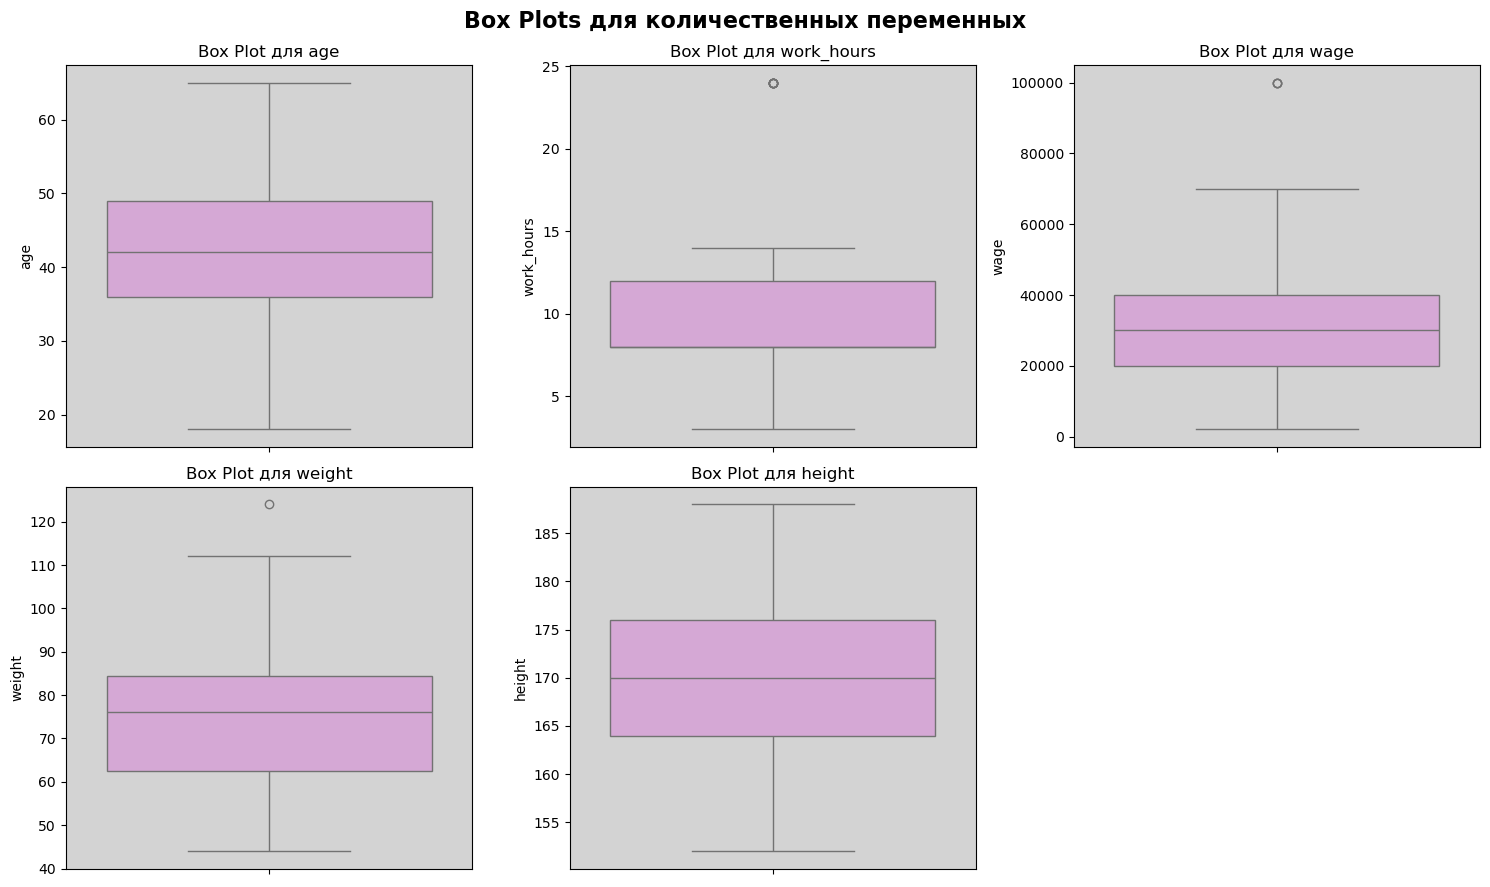

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

columns_to_plot = ['age', 'work_hours', 'wage', 'weight', 'height']


for i, col in enumerate(columns_to_plot):
    sns.boxplot(data=df, y=col, ax=axes[i], color='plum')
    axes[i].set_title(f'Box Plot для {col}', fontsize=12)
    axes[i].set_facecolor('lightgray')


axes[-1].axis('off')
fig.suptitle('Box Plots для количественных переменных', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('Box Plots для количественных переменных.png')
plt.show()

В целом, в предыдущем пункте мы заметили, что в wage и work_hours есть выбросы, но на этих графиках также видно, что выбросы есть в weight.

## 6. 

**Постройте гистограммы распределения для количественных переменных в выборке. Что можно сказать о скошенности (асимметрии) и островершинности их распределений? Рассчитайте соответствующие показатели (Skewness
и Kurtosis) и сделайте выводы.**

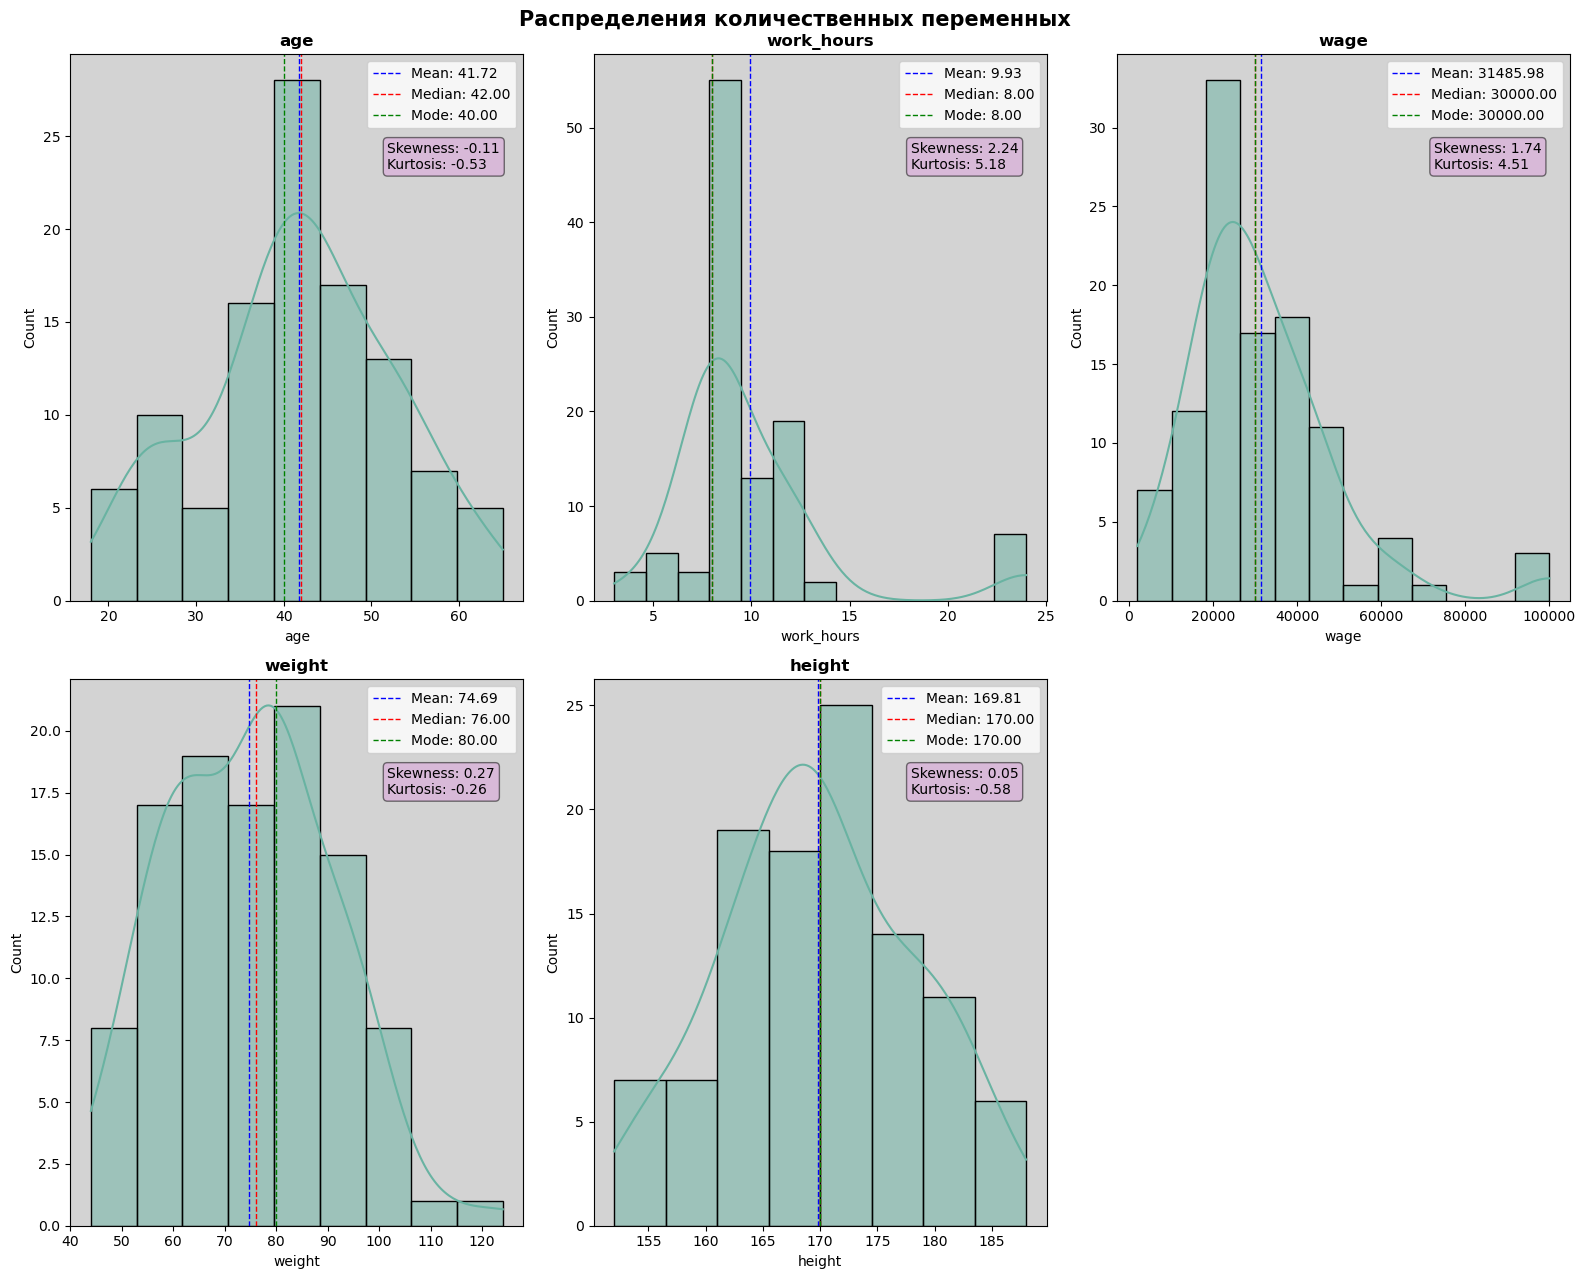

In [13]:
skew_and_kurt = []

def plot_histogram_with_stats(data, column_name, ax):
    
    mean = stata.loc['mean', col]
    median = stata.loc['median', col]
    mode = stata.loc['mode', col]
    skewness = skew(data)
    kurtosis_ = kurtosis(data)
    
    skew_and_kurt.append((column_name, skewness, kurtosis_))
    
    sns.histplot(data, ax=ax, kde=True, color="#69b3a2") 
    ax.axvline(mean, color='blue', linestyle='dashed', linewidth=1, label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='red', linestyle='dashed', linewidth=1, label=f'Median: {median:.2f}')
    ax.axvline(mode, color='green', linestyle='dashed', linewidth=1, label=f'Mode: {mode:.2f}')

    props = dict(boxstyle='round', facecolor='plum', alpha=0.5)
    ax.text(0.70, 0.84, f'Skewness: {skewness:.2f}\nKurtosis: {kurtosis_:.2f}',
      transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
    
    ax.set_title(column_name, weight='bold')
    ax.set_facecolor('lightgray')
    ax.legend()

    

fig, axes = plt.subplots(2, 3, figsize=(16, 13))
axes = axes.flatten()

columns_to_plot = ['age', 'work_hours', 'wage', 'weight', 'height']


for i, col in enumerate(columns_to_plot):
  plot_histogram_with_stats(df[col], col, axes[i])
    
fig.suptitle('Распределения количественных переменных', fontsize=15, weight='bold')
axes[-1].axis('off')
plt.tight_layout() 
plt.savefig('Распределения количественных переменных.png')
plt.show()

In [14]:
num = 1

print('ВЫВОДЫ')
print()

for col, skew, kurt in skew_and_kurt:
    print(f'{num}. {col}')
    descr_1 = ['-', 'не сильн', 'сильн']
    descr_2 = ['-', 
               'сдвиг в сторону меньших значений относительно среднего (положительная скошенность)', 
               'cдвиг в сторону бOльших значений относительно среднего (отрицательная скошенность)',
              ]
    descr_3 = ['-', 
               'островершинность, распределение вытянуто вверх в сравнении с нормальным (скопление частот в середине)', 
               'плосковешинноть (частоты более рассеянны относительно среднего)']
    outliers = 'близко к нормальному' if np.sign(1 - abs(skew)) + 1 else 'может быть сигналом выбросов'  
    print(f"Skewness = {skew:.2f}: в распределении {descr_1[int(np.sign(1 - abs(skew)))]}ый {descr_2[int(np.sign(skew))]}, {outliers}. Kurtosis = {kurt:.2f}: {descr_1[int(np.sign(1 - abs(kurt)))]}ая {descr_3[int(np.sign(kurt))]}")
    print()
    num += 1
    

ВЫВОДЫ

1. age
Skewness = -0.11: в распределении не сильный cдвиг в сторону бOльших значений относительно среднего (отрицательная скошенность), близко к нормальному. Kurtosis = -0.53: не сильная плосковешинноть (частоты более рассеянны относительно среднего)

2. work_hours
Skewness = 2.24: в распределении сильный сдвиг в сторону меньших значений относительно среднего (положительная скошенность), может быть сигналом выбросов. Kurtosis = 5.18: сильная островершинность, распределение вытянуто вверх в сравнении с нормальным (скопление частот в середине)

3. wage
Skewness = 1.74: в распределении сильный сдвиг в сторону меньших значений относительно среднего (положительная скошенность), может быть сигналом выбросов. Kurtosis = 4.51: сильная островершинность, распределение вытянуто вверх в сравнении с нормальным (скопление частот в середине)

4. weight
Skewness = 0.27: в распределении не сильный сдвиг в сторону меньших значений относительно среднего (положительная скошенность), близко к норма

## 7.

**Как распределены респонденты в Вашей выборке по уровню образования? Постройте гистограмму**


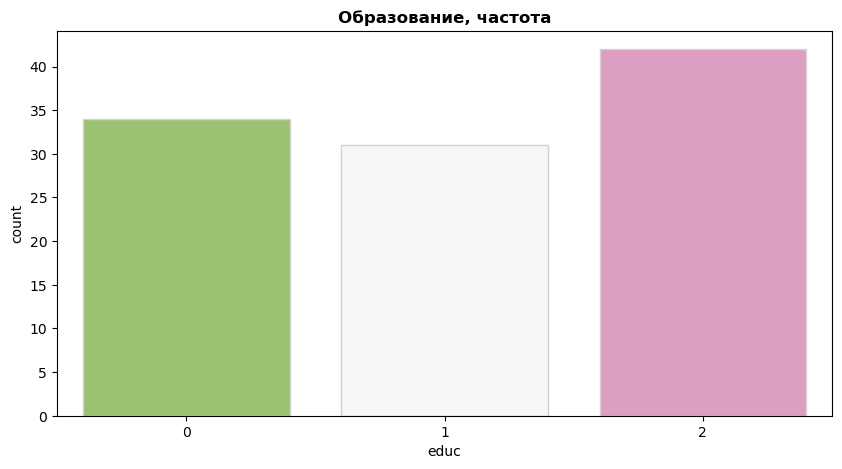

In [15]:
plt.figure(figsize = (10, 5))
for_plot = df['educ'].value_counts().reset_index()
ax = sns.barplot(data=for_plot, x='educ', y='count', palette='PiYG_r')
ax.set_title('Образование, частота', weight='bold')

for p in ax.patches:
  p.set_edgecolor('lightgrey')
  p.set_linewidth(1);

plt.savefig('Образование.png')

Заметим, что по уровню образования респонденты распределены достаточно равномерно, тем не менее преобладает число людей, у которых есть высшее образование (категория 2)

In [16]:
numeric = ['age', 'work_hours', 'wage', 'weight', 'height']
cat = ['female', 'foreign_language', 'internet', 'alcohol', 'is_children', 'health', 'smoke']

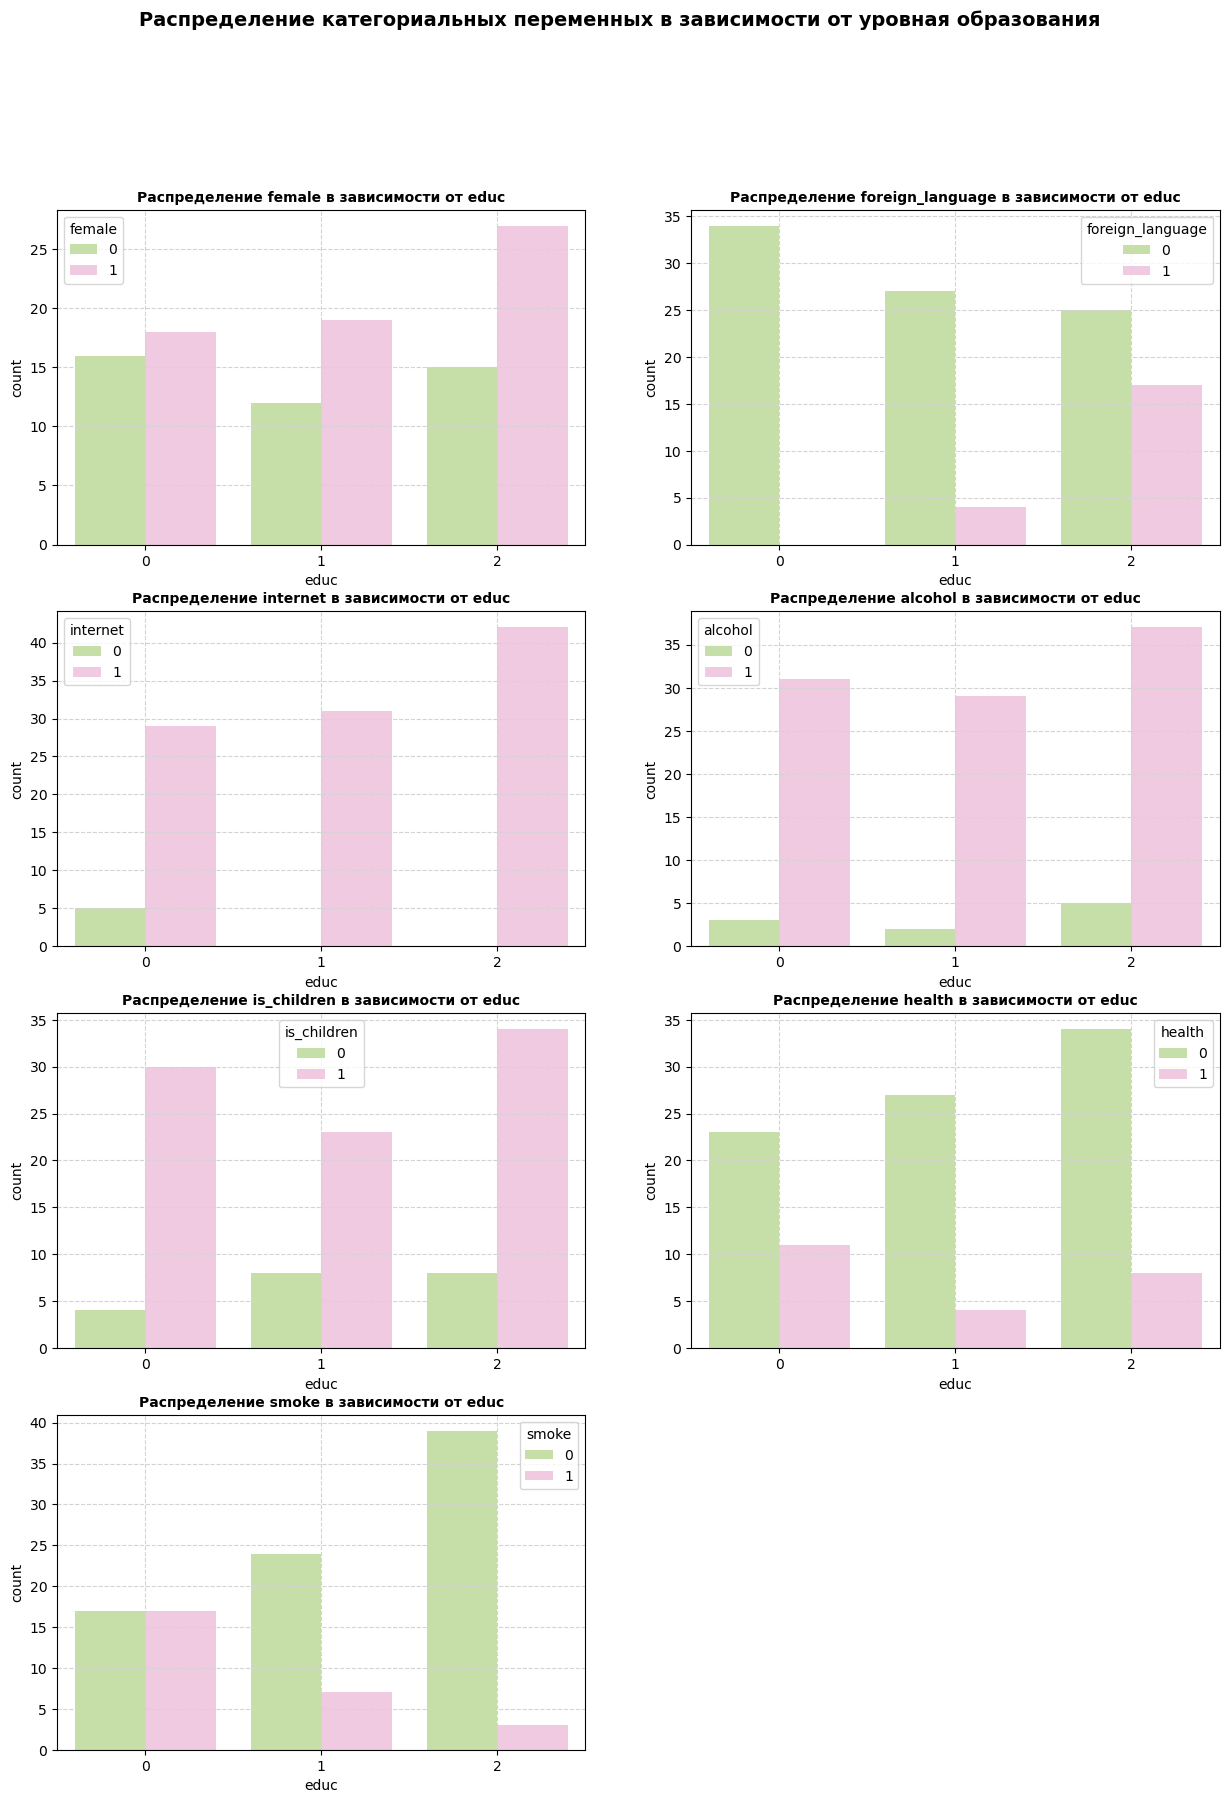

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
fig.suptitle('Распределение категориальных переменных в зависимости от уровная образования', fontsize=14, weight='bold')
axes = axes.flatten()

for i, col in enumerate(cat):
    sns.countplot(x='educ', hue=col, data=df, palette='PiYG_r', ax=axes[i])
    axes[i].set_title(f'Распределение {col} в зависимости от educ', fontsize=10, weight='bold')
    axes[i].grid(color='lightgrey', linestyle='--')

axes[-1].axis('off')
#axes[-2].axis('off')
plt.savefig('Распределение категориальных переменных в зависимости от уровная образования.png')
plt.show()

Влияние категориальных переменных на распредление образования:

-  female: заметим, что женщин в данных в принципе больше, поэтому по графику сложно оценить влияние пола на уровень образования, но на первый взгляд кажется, что женщины получают высшее образование чаще (разрыв между столбцами выше чем для других уровней образования)

-  foreign_language: люди с высшим образование значительно чаще знают иностранный язык.

-  internrt: интернетом пользуются все, но лишь в группе 0 можно наблюдать респондентов, которые не использовали интернет последний год.

-  alchohol: все распределено довольно равномерно (разница не слишком сушественная, чтобы говорить о каких-то связях)

-  is_children: аналогично, все довольно равномерно

-  health: нельзя сказать, что есть очевидная взаимосвязь, но как будто люди с высшим образованием реже испытывают проблемы со здоровьем

-  smoke: для данной переменной взаимосвязь очевидна - чем выше уровень образование, тем меньше вероятность, что респондент курит

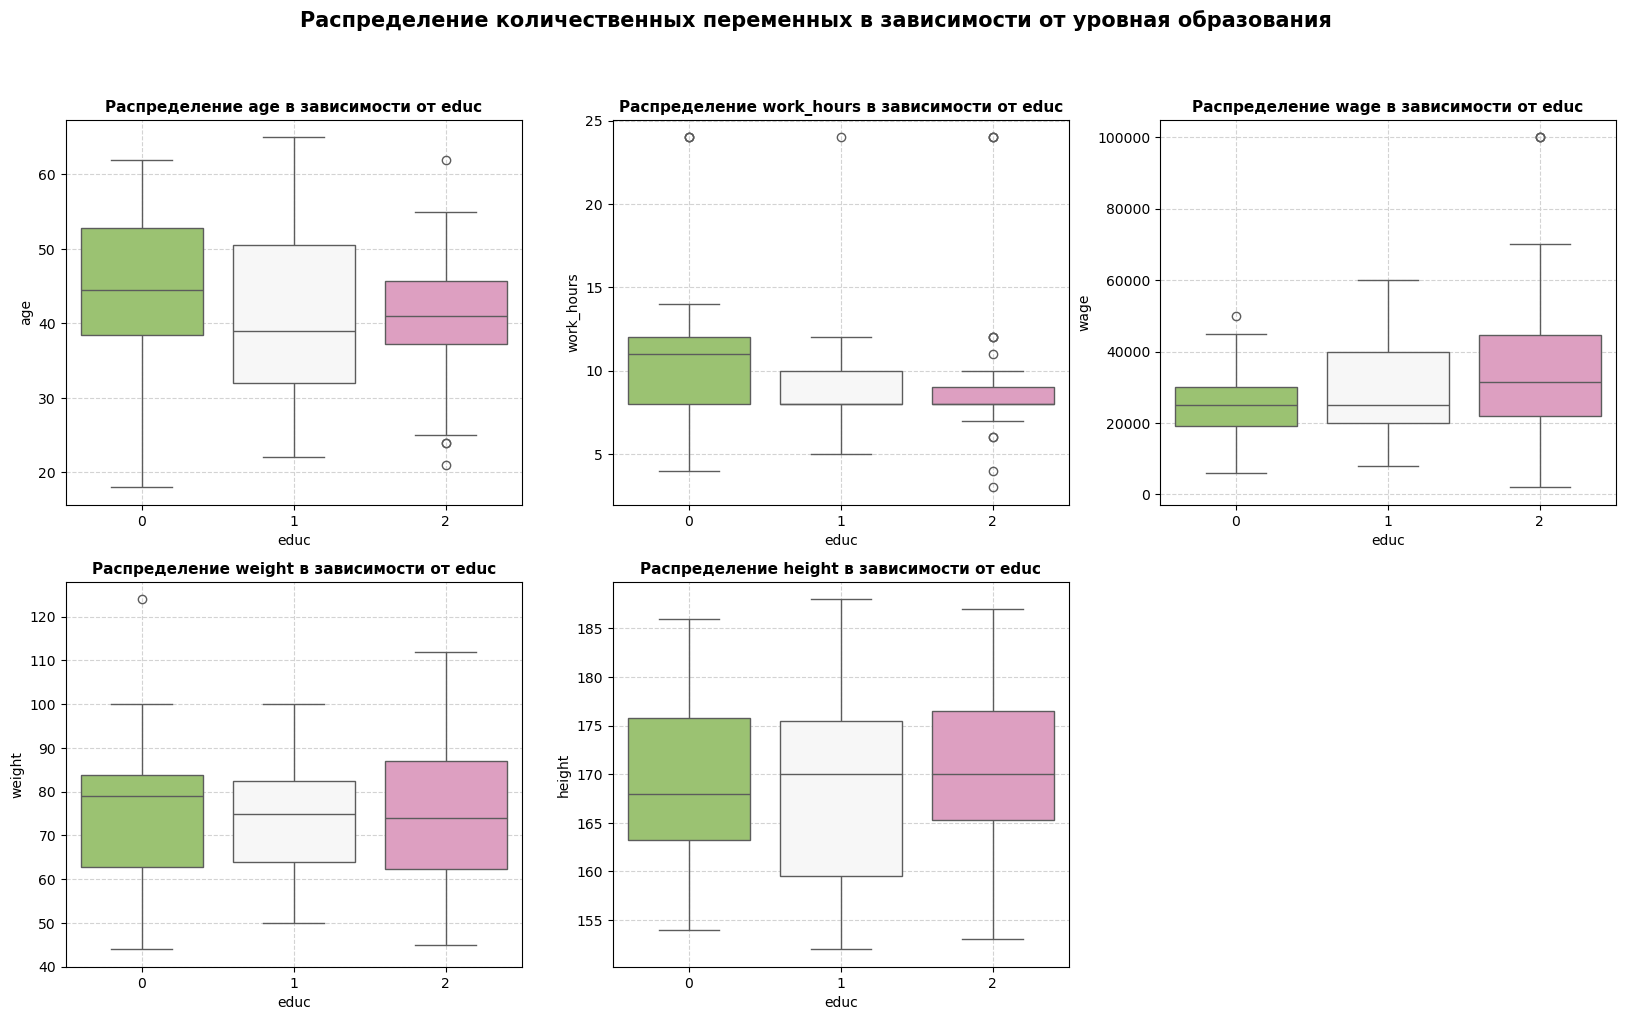

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Распределение количественных переменных в зависимости от уровная образования', fontsize=15, weight='bold')
axes = axes.flatten()

for i, col in enumerate(numeric):
    sns.boxplot(x='educ', y=col, data=df, palette='PiYG_r', ax=axes[i])
    axes[i].set_title(f'Распределение {col} в зависимости от educ', fontsize=11, weight='bold')
    axes[i].grid(color='lightgrey', linestyle='--')

axes[-1].axis('off')

plt.savefig('Распределение количественных переменных в зависимости от уровная образования.png')
plt.show()

Влияние количественных переменных на уровень образования:

- age: группа 0 чуть более возрастная, чем группа 2, что говорит о том, что получение высшего образование - более современный тренд, группа 1 наиболее разнообразна на возраста.

- work_hour: люди из группы 0 и 1 имеют более широкий диапазон часов работы, в то время как люди из группы 2 работают в среднем мЕньшее количество часов и основная концентрация значений в районе 7-9.

- wage: из графика очевидно, что чем ввше уровень образования, тем в среднем больше респондент зарабатывает.

- weight: люди группы 2 имеют более широки диапазон значений, да и в целом в этой группе чаще встречаются респонденты с весом более 80

- height: на мой скромный взгляд взаимосвязи особой нет.

## 8.

**Постройте корреляционную таблицу для всех переменных в Вашей выборке кроме отрасли, региона и года. Проинтерпретируйте результаты**

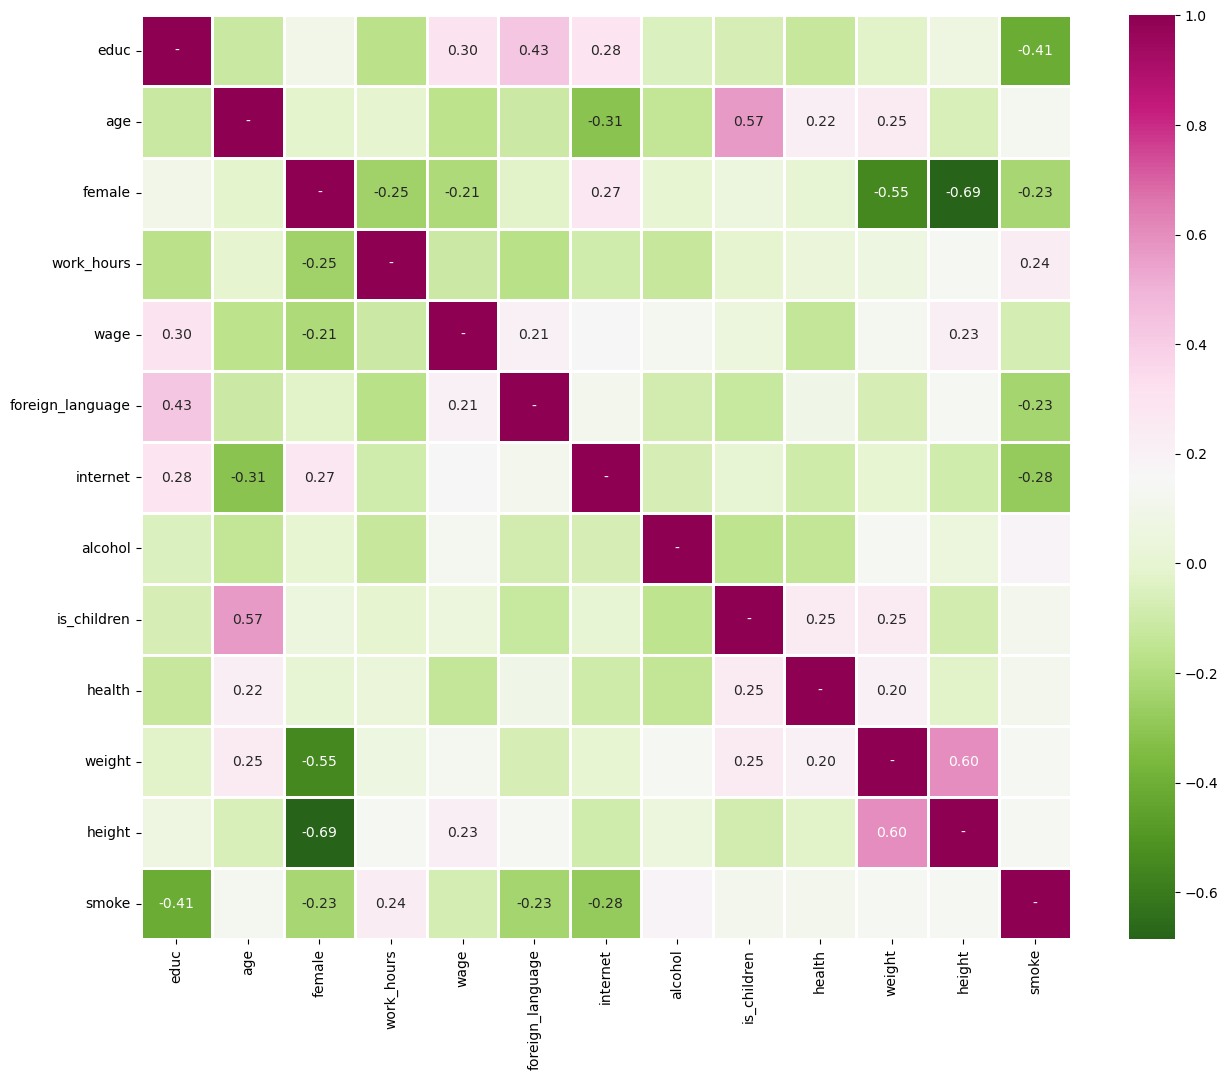

In [19]:
plt.figure(figsize = (15,12))

colormap = plt.cm.PiYG_r
ax = sns.heatmap(df.drop(columns={'region', 'industry', 'year'}).corr(), cmap=colormap, linewidths=1, annot=True, fmt=".2f")

for t in ax.texts:
    if abs(float(t.get_text())) == 1:
        t.set_text('-')
    elif abs(float(t.get_text())) < 0.2:
        t.set_text('')

plt.savefig('Матрица корреляций.png')

Какие переменные скоррелированы? Я буду рассматривать корреляции, которые по модулю превышают 0.2

- Как мы отмечали в прошлом пункте из матрицы корреляций видна положительная линейная связь между educ и: wage (бОльшая ЗП у людей с высшим образованием), foreign_language (люди с вышим образованием чаще знают иностранные языки), internet, а также отрицательная связь с переменной smoke (чем выше уровень образование, тем меньше вероятность что респондент курит).

- Age отрицательно связан с internet (чем старше человек, тем больше вероятность, что он не использовал интренет в течение года). Возраст положительно связан с наличием детей (чем старше человек, тем больше вероятность, что у него есть дети), здоровьем (чем страше человек, тем больше вероятность проблем со здоровьем) и весов (у более взрослых людей в наших данных вес выше).

- Female: отрицательная связь с количеством часов (женщины работают меньше), с уровнем ЗП (женщины получают меньше), с весом, ростом и склонностью курить, при этом положительная связь с использованием интернета (среди мужчин чаще встречаются те, кто не использовал интернет больше года)

- Люди с детьми весят больше и имею больше проблем со здоровьем)) ***Не является пропагандой чайлдфри

# 9.

**Предположите зависимость заработной платы от каких-либо переменных в 
файле. Постройте графики, которые позволяют продемонстрировать эту зависимость.**

Судя по анализу выше наибольшая линейная взаимосвязь ЗП наблюдается с переменной educ, female и foreign_language. График зависимости:

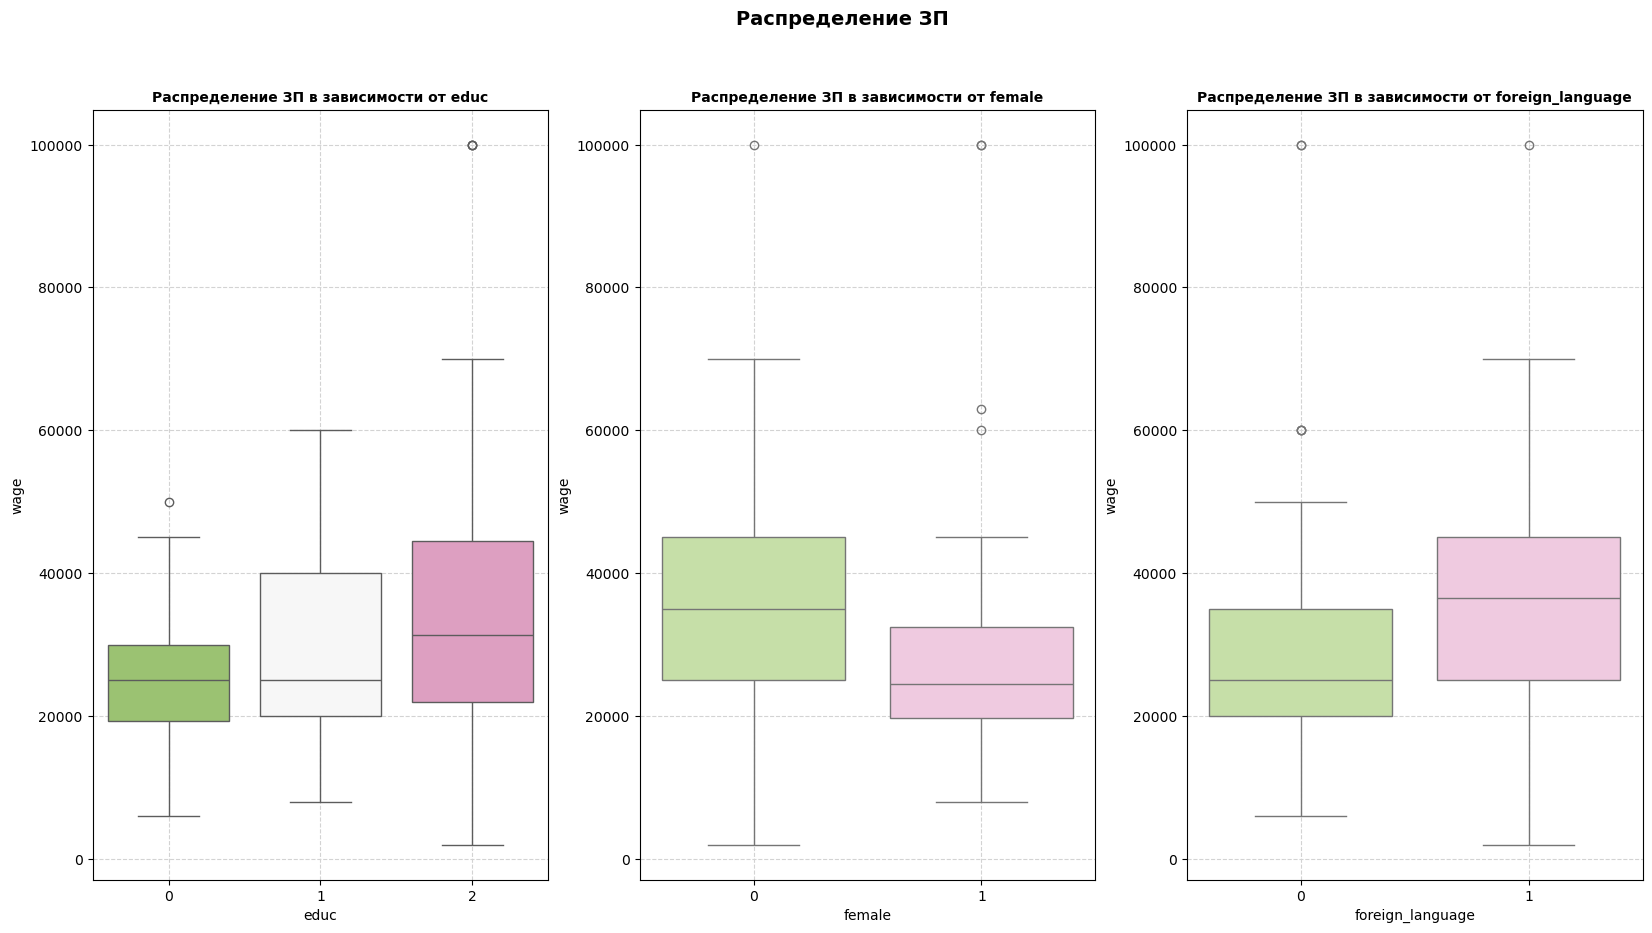

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
fig.suptitle('Распределение ЗП', fontsize=14, weight='bold')
axes = axes.flatten()

feats = ['educ', 'female', 'foreign_language']
for i, col in enumerate(feats):
    sns.boxplot(y='wage', x=col, data=df, palette='PiYG_r', ax=axes[i])
    axes[i].set_title(f'Распределение ЗП в зависимости от {col}', fontsize=10, weight='bold')
    axes[i].grid(color='lightgrey', linestyle='--')

plt.savefig('Распределение ЗП.png')
plt.show()

## 10.

**Оцените линейную модель, которая объясняет заработную плату (wage) возрастом (age), наличием высшего образования (high), полом (female), наличием
детей (is_children), курением (smoke) и константой. Проинтерпретируйте полученные результаты. Все ли коэффициенты оказались значимы? Выпишитеуравнение оцененной модели**

In [21]:
# создадим переменную high

df['high'] = (df['educ'] == 2).astype('int')

In [22]:
X = sm.add_constant(df[['age', 'high', 'female', 'is_children', 'smoke']])
y = df['wage']

model_stats = sm.OLS(y, X).fit()

print(model_stats.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     4.604
Date:                Sun, 24 Nov 2024   Prob (F-statistic):           0.000797
Time:                        21:36:56   Log-Likelihood:                -1186.4
No. Observations:                 107   AIC:                             2385.
Df Residuals:                     101   BIC:                             2401.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        4.345e+04   6957.178      6.245      

In [23]:
# попробуем получить оценки и другим способом (заметим, что они совпали)

model = LinearRegression()
model.fit(X,y)

coefs = [model.intercept_]
coefs.extend(model.coef_[1:])

pd.DataFrame({'value': pd.Series(coefs, index=['const', 'age', 'high', 'female', 'is_children', 'smoke'])})

,value
const,43450.038927
age,-432.382040
high,9953.447134
female,-8854.127602
is_children,9515.873185
smoke,-1083.789527


$$
\hat {wage} = 43450.038927362366 -432.3820 \times \text{age} + 9953.4471 \times \text{high} -8854.1276 \times \text{female} + 9515.8732 \times \text{is\_children} -1083.7895 \times \text{smoke}
$$

Интерпретация результатов:

- age: при тестировании гипотезы о равенстве коэффициенты при данной перемене нулю, мы получили p_value = $1.8\%$ => минимальный уровнь значимости, который бы мы должны были выбрать, чтобы отвергнуть гипотезу = $1.8\%$. Таким образом, на классических уровнях значимости $5\%$ или $10\%$ гипотеза о незначимости признака отвергается. Согласно оценке нашей моледи при увеличении возраста на единицу человек будтет терять 432.3820 в зарплате.

- high: при тестировании гипотезы о равенстве коэффициенты при данной перемене нулю, мы получили p_value = $0.5 \%$ => минимальный уровнь значимости, который бы мы должны были выбрать, чтобы отвергнуть гипотезу = $0.5 \%$. Таким образом, на классических уровнях значимости $5\%$ или $10%$ гипотеза о незначимости признака отвергается. Сгласно оценке нашей моледи наличие высшего образование обеспчивает прирост к зарплате равный 9953.4471.


- female: при тестировании гипотезы о равенстве коэффициенты при данной перемене нулю, мы получили p_value = $0.9 \%$ => минимальный уровнь значимости, который бы мы должны были выбрать, чтобы отвергнуть гипотезу = $0.9 \%$. Таким образом, на классических уровнях значимости $5\%$ или $10%$ гипотеза о незначимости признака отвергается. Тогда согласно оценке нашей моледи, если респондент оказывается женщиной, то прогноз по его зарплате при прочих равных будет на 8854.1276 меньше чем у мужчины.

- is_children: при тестировании гипотезы о равенстве коэффициенты при данной перемене нулю, мы получили p_value = $5.7 \%$ => минимальный уровнь значимости, который бы мы должны были выбрать, чтобы отвергнуть гипотезу = $5.7 \%$. Таким образом, гипотеза о незначимости данного признака не может быть отвергнута на $5 \%$-ом уровне значимости. Заметим также не слишком очевидное на первый взгляд сильное влияние данного признака на прогноз модели: наличие детей согласно оценке модели увеличит ее прогноз на 9515.8732 при прочих равных (возможно, наличие детей влият на зарплатные ожидания респондентов, и они ищут работу с большей оплатой труда, поскольку несут ответсвенность за детей, и именно эту закономерность отследила модель при оценке коэффициента при переменной).

- smoke: при тестировании гипотезы о равенстве коэффициенты при данной перемене нулю, мы получили p_value = $78.6 \%$ => минимальный уровнь значимости, который бы мы должны были выбрать, чтобы отвергнуть гипотезу = $78.6 \%$. Таким образом, гипотеза о незначимости данного коэффициента не может быть отвергнута на любом разумном уровне значимости. При этом согласно оценке коэффициента при данном признаке: курение отрицательно влияет на уровень ЗП.

## 11.

**Выполните тест на адекватность этой модели и сделайте выводы.**

Будем тестировать гипотезу о незначимости модели в целом (все коэффиценты, кроме константы = 0)

Запишем основную и альтернативную гипотезы

$$
H_0:
\begin{cases}
\beta_{age} = 0\\
\beta_{high} = 0\\
\beta_{female} = 0\\
\beta_{is_children} = 0\\
\beta_{smoke} = 0
\end{cases}
$$

$$
H_1:\beta_{age} \neq 0 | \beta_{high} \neq 0| \beta_{female} \neq 0 | \beta_{ischildren} \neq 0 | \beta_{smoke} \neq 0
$$

($Н_1$ - хотя бы один из параметров не равен 0)

Для решения будем использовать F-статистику, которая при верной $Н_0$ имеет следующее распределение:

$$ F = \cfrac{ESS / (k-1)}{RSS/(n-k)} \sim F_{k-1, n-k}$$

$$ RSS = (y - \hat y)'(y - \hat y)$$

$$ ESS = (\hat y - \bar y)'(\hat y - \bar y)$$

, где $k-1=6-1=5$ и $n-k=107-6=101$

**Первый способ:** используем summery модели.

In [24]:
print(f'Значение p-value F-теста: {model_stats.f_pvalue}') 
print(f'Критическое значение статистики: {stats.f.ppf(0.95, 5, 101)}')
print(f'Расчетное значение статистики {model_stats.fvalue}')

Значение p-value F-теста: 0.0007967291334995284
Критическое значение статистики: 2.30439641654243
Расчетное значение статистики 4.603907954116526


**Второй способ:** прописываем гипотезу ручками

In [25]:
hypotheses = '(age = high = female = is_children = smoke = 0)' # H_0
print(model_stats.f_test(r_matrix = hypotheses)) # F-тест

<F test: F=4.60390795411696, p=0.0007967291334989047, df_denom=101, df_num=5>


**Третий способ:** считаем все по формуле

In [26]:
y_pred = model.predict(X)
y_mean = np.mean(y)

ESS = np.sum((y_pred - y_mean)**2)

TSS = np.sum((y - y_mean)**2)

RSS = np.sum((y - y_pred)**2)

F_obs = (ESS/5) / (RSS/101)
F_crit = stats.f.ppf(0.95, 5, 101)
p_value = 1 - stats.f.cdf(F_obs, 5, 101)

print(f'Значение p-value F-теста: {p_value}') 
print(f'Критическое значение статистики: {F_crit}')
print(f'Расчетное значение статистики {F_obs}')

Значение p-value F-теста: 0.0007967291334994853
Критическое значение статистики: 2.30439641654243
Расчетное значение статистики 4.603907954116536


Заметим, что все три способа дали идентичные результаты.

**Интерпретация:**

При тестировании гипотезы об адекватности модели, мы получили p_value = $0.07 \%$ => минимальный уровнь значимости, который бы мы должны были выбрать, чтобы отвергнуть гипотезу = $0.07 \%$ (этот и все те, что больше). Таким образом, гипотеза о незначимости модели в целом отвергается на любом разумном уроврне значимости. Но заметим, что значение $R^2$ не слишком большое, что говорит о том, что модель объясняет зависимости в данных не сильно лучше, чем модель построенная просто на среднем.

## 12.

**Сформулируйте и протестируйте гипотезу для одного из коэффициентов модели. Дайте содержательную и количественную интерпретацию полученных
результатов.**

Будем тестировать гипотезу о том, что коэффициент при переменной is_female = 1. Проверим можно ли на основе наших данных предположить, что факт того, что респондент женщина может служить приросту к ЗП хотя бы на одну единицу. 

Запишем основную и альтернативную гипотезы

$$Н_0: \beta_{is_female} = 1$$

$$H_1: \beta_{is_female} \neq 1$$

Для решения будем использовать Т-статистику, которая при верной $Н_0$ имеет следующее распределение:

$$ T = \cfrac{\hat \beta - 1}{se(\hat \beta)} \sim t_{n - k} $$

, где $n-k = 107 - 5 = 101$

In [27]:
hypotheses_2 = '(female = 1)'
print(model_stats.t_test(r_matrix = hypotheses_2))

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0         -8854.1276   3305.771     -2.679      0.009   -1.54e+04   -2296.367


In [28]:
t_obs = -2.679
t_crit = stats.t.ppf(0.975, 101)
p_value = 2 * stats.t.cdf(t_obs, 101)

print(f'Значение p-value t-теста: {p_value}') 
print(f'Критическое значение статистики: {t_crit}')
print(f'Расчетное значение статистики {t_obs}')

Значение p-value t-теста: 0.008622132116088138
Критическое значение статистики: 1.983731002885281
Расчетное значение статистики -2.679


При тестировании гипотезы о равенстве коэффициента при is_female единице, мы получили p_value = $0.9 \%$ => минимальный уровнь значимости, который бы мы должны были выбрать, чтобы отвергнуть гипотезу = $0.9 \%$ (иначе говоря, вероятность встретить это и еще менее вероятные значения =  $0.9 \%$). Таким образом, гипотеза о том, что есть хотя бы небольшой прирост в ЗП в связи с принадлежностью к женскому полу - отвергается на любом разумном уровне значимости. 

Этот же вывод мы можем получить, если сравним критическое значение статистики на $5 \%$ уроне значимости с расчетным (наблюдаемым) знаечнием: расчетное значение выходит за область доверия [-t_crit, t_crit], поэтому гипотеза отвергается

## 13.

**Сформулируйте и протестируйте гипотезу о нескольких коэффициентах модели. Дайте содержательную и количественную интерпретацию полученных
результатов.**

Запишем основную и альтернативную гипотезы

$$Н_0: \beta_{female} + \beta_{high} = 0$$

$$H_1: \beta_{female} + \beta_{high} \neq 0$$

Для решения будем использовать Т-статистику, которая при верной $Н_0$ имеет следующее распределение:

$$ T = \cfrac{\hat \beta_1 + \hat \beta_2 - 0}{se(\hat \beta_2 + \hat \beta_2)} \sim t_{n-k} $$

Пояснение: $\hat \beta_1$ имеет нормальное распредление,  $\hat \beta_2$ тоже имеет нормальное распредление => их сумма имеет нормальное распределение. $se(\hat {\beta_1} + \hat {\beta_2}) = \sqrt {\hat {Var} (\hat {\beta_1} + \hat {\beta_2})} = \sqrt {\hat {Var} (\hat {\beta_1}) +  \hat {Var} (\hat {\beta_2}) +  2\hat {cov} (\hat {\beta_1}, \hat {\beta_2})} $.

In [29]:
hypotheses_3 = '(female+high=0)'
print(model_stats.t_test(r_matrix = hypotheses_3)) 

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0          1099.3195   4779.761      0.230      0.819   -8382.441    1.06e+04


In [30]:
t_obs = 0.230
t_crit = stats.t.ppf(0.975, 101)
p_value = 2 * stats.t.cdf(-t_obs, 101)

print(f'Значение p-value t-теста: {p_value}') 
print(f'Критическое значение статистики: {t_crit}')
print(f'Расчетное значение статистики {t_obs}')

Значение p-value t-теста: 0.8185569497735536
Критическое значение статистики: 1.983731002885281
Расчетное значение статистики 0.23


При тестировании гипотезы о том, что сумма коэффициентов при female и hight равна 0, мы получили p_value = $82\%$ => минимальный уровнь значимости, который бы мы должны были выбрать, чтобы отвергнуть гипотезу = $82 \%$ (иначе говоря, вероятность встретить это и еще менее вероятные значения =  $82 \%$). Таким образом, данную гипотезу нельзя отвергнуть на классических уровнях значимости ($5\%$, $10\%$)

Этот же вывод мы можем получить, если сравним критическое значение статистики на $5 \%$-ом уроне значимости с расчетным (наблюдаемым) знаечнием: расчетное значение лежит внутри области доверия [-t_crit, t_crit], поэтому гипотезу отвергнуть нельзя.

Содержательно можно интерпретировать результат следующим образом: прирост в ЗП вызванный ростом образования на одну единицу (переход от школьного образования к ПТУ, от ПТУ к высшему) может быть полностью невелирован фактом того, что респондент женщина при прочих равных.

## 14.

**Постройте график «остатки–прогнозы». Сделайте вывод.**

Остатки, среднее значение: 0.00


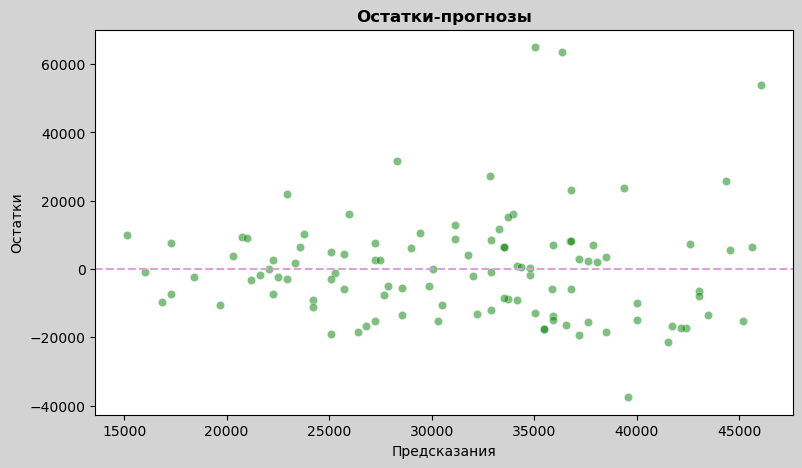

In [31]:
preds = model_stats.fittedvalues
residuals = model_stats.resid
residuals_mean = np.mean(model_stats.resid)
print(f'Остатки, среднее значение: {residuals_mean:.2f}')

plt.figure(figsize=(9, 5), facecolor='lightgray')
sns.scatterplot(x=preds, y=residuals, alpha=0.5, color='green')
plt.title('Остатки-прогнозы', weight='bold')
plt.xlabel('Предсказания')
plt.ylabel('Остатки')
plt.axhline(y=residuals_mean, color='plum', linestyle='--')
plt.savefig('Остатки-прогнозы.png')
plt.show()

Заметим, что не наблюдается какая-то явная зависимость отсатков от прогнозов, что может говорить об отсутствии гетероскедастичности и верной функциональной форме.
При отсутствии гетероскедастичности и верной функциональной форме график должен выглядеть как бессистемное облако точек вокруг среднего значения, равного нулю. Именно это мы и наблюдаем в наших данных. 

Обычно график «остатки-прогнозы» позволяет выявить 
гетероскедастичност  и ошибку функциональной форм. Но в наших данных все хорошо, хотя можно наблюдать 2-3 выброса в значении остатков для больших прогнозов (по всей видимости модель выдала предсказание сильно выше реального значения), тем не менее их немного, поэтому в целом наша модель хорошо подходит под данные.

# 15.

**Оцените модель из п. 10, оставив в ней только значимые коэффициенты. Выпишите уравнение оцененной модели. Сравните результаты с моделью из п. 10.
Какие критерии для сравнения моделей здесь стоит использовать?**

In [32]:
X_2 = sm.add_constant(df[['age', 'high', 'female']])
y = df['wage']

model_stats_2 = sm.OLS(y, X_2).fit()

print(model_stats_2.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     6.329
Date:                Sun, 24 Nov 2024   Prob (F-statistic):           0.000555
Time:                        21:36:56   Log-Likelihood:                -1188.3
No. Observations:                 107   AIC:                             2385.
Df Residuals:                     103   BIC:                             2395.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.223e+04   6890.968      6.129      0.0

In [33]:
# попробуем получить оценки и другим способом (заметим, что они совпали)

model_2 = LinearRegression()
model_2.fit(X_2,y)

coefs_2 = [model_2.intercept_]
coefs_2.extend(model_2.coef_[1:])

pd.DataFrame({'value': pd.Series(coefs_2, index=['const', 'age', 'high', 'female'])})

,value
const,42234.469068
age,-237.990006
high,10498.388091
female,-8259.892221


$$
\hat {wage} = 42234.469068 -237.990006 \times \text{age} + 10498.388091 \times \text{high} -8259.892221 \times \text{female} 
$$

In [34]:
pd.options.display.float_format = '{:.2f}'.format

def compare_models(model1, model2, X, y, X_2):
    
    results = {
    'Model 1': [],
    'Model 2': []
    }
    
    results['Model 1'].extend([
            model1.rsquared,
            model1.rsquared_adj,
            model1.aic,
            model1.bic,
            np.sqrt(mean_squared_error(y, model1.predict(sm.add_constant(X))))
    ])
    results['Model 2'].extend([
            model2.rsquared,
            model2.rsquared_adj,
            model2.aic,
            model2.bic,
            np.sqrt(mean_squared_error(y, model2.predict(sm.add_constant(X_2))))
    ])

    return pd.DataFrame(results, index=['R-squared', 'Adjusted R-squared', 'AIC', 'BIC', 'RMSE (Training)']).round(2)

comparison_table = compare_models(model_stats, model_stats_2, X, y, X_2)
comparison_table

,Model 1,Model 2
R-squared,0.19,0.16
Adjusted R-squared,0.15,0.13
AIC,2384.73,2384.60
BIC,2400.77,2395.29
RMSE (Training),15813.06,16101.32


Для сравнения я использую такие критерии как R-squared, Adjusted R-squared, AIC, BIC, RMSE (Training).

- R-квадрат: Показывает долю дисперсии зависимой переменной, объясняемую моделью. Более высокое значение R-квадрат указывает на лучшую подгонку под данные. Однако, он увеличивается с добавлением признаков, даже если эти признаки неинформативны, поэтому я также смотрю на Adjusted R-squared.

- Adjusted R-squared : Аналогичен R-квадрату, но скорректирован на число признаков в модели. Он штрафует за включение ненужных переменных.

- AIC: Мера качества подгонки модели, которая учитывает предсказательную способность модели и штрафует за сложность (много признаков). Более низкие значения AIC указывают на лучшие модели.

- BIC: Аналогичен AIC, но за сложность модели штрафует сильнее. Более низкие значения BIC указывают на лучшие модели.
  
- RMSE: Квадратный корень из среднего квадратов разностей между фактическими и предсказанными значениями. Более низкое значение RMSE указывает на лучшую точность прогнозирования.

In [35]:
r_sq = 'Модель 1 показывает более высокое качество R^2 (19% против 16%), это говорит о более высокой объясняющей способности.'
r_sq_adj = 'Модель 1 справляется лучше даже после корретировки на число признаков, но разница уменьшилась (15% против 13%).'
aic_ = 'Модель 2 имеет немного меньшее AIC, что указывает на незначительно лучшую балансировку между качеством прогноза и сложностью модели.'
bic_ = 'Модель 2 имеет заметно меньшее BIC, что указывает на заметно лучшую балансировку между качеством прогноза и сложностью модели.'
rmse = 'Модель 1 имеет меньшее RMSE, что говорит о том, что итоговое качество предсказания у нее лучше.'

comparison_table['Интерпретация'] = [r_sq, r_sq_adj, aic_, bic_, rmse]

def add_horizontal_lines(row):
  return [f"border-bottom: 1px dashed grey;"] * len(row)
    
comparison_table_st = comparison_table.style.set_properties(**{'background-color': 'white',
                        'color': 'black',
                        'border-color': 'grey',
                        'border-width': '1px', 
                        'border-style': 'dashed'}) \
                       .set_table_styles([
                         {'selector': 'th', 'props': [('background-color', 'plum'),
                                       ('color', 'black'),
                                       ('text-align', 'center')]},
                         {'selector': 'td:nth-child(n+2)', 'props': [
                                       ('color', 'black'),
                                       ('text-align', 'left')]}
                       ])\
                 .apply(add_horizontal_lines, axis=1)

dfi.export(comparison_table_st, 'comparison_table_st.png')
comparison_table_st

,Model 1,Model 2,Интерпретация
R-squared,0.190000,0.160000,"Модель 1 показывает более высокое качество R^2 (19% против 16%), это говорит о более высокой объясняющей способности."
Adjusted R-squared,0.150000,0.130000,"Модель 1 справляется лучше даже после корретировки на число признаков, но разница уменьшилась (15% против 13%)."
AIC,2384.730000,2384.600000,"Модель 2 имеет немного меньшее AIC, что указывает на незначительно лучшую балансировку между качеством прогноза и сложностью модели."
BIC,2400.770000,2395.290000,"Модель 2 имеет заметно меньшее BIC, что указывает на заметно лучшую балансировку между качеством прогноза и сложностью модели."
RMSE (Training),15813.060000,16101.320000,"Модель 1 имеет меньшее RMSE, что говорит о том, что итоговое качество предсказания у нее лучше."


Результаты очень близки, что говорит о схожей производительности обеих моделей в объяснении зависимостей в данных. Модель 2 имеет немного меньшуие AIC и BIC, но большее RMSE. Однако, различия незначительны. Для окончательного выбора можно учесть:

• Практическая значимость: Являются ли различия в AIC, BIC и RMSE практически значимыми. Небольшое улучшение AIC/BIC может быть неважным, если снижается точность прогноизирования.

• Качество на тестовой выборке: Обе модели можно оценить на новых данных и если разницы будет небольшая, то для большей производительности (из-за меньшего числа признаков) можно выбрать вторую модель (особенно актульно для больших выборок, где прогнозирование занимает очень много времени, поэтому чем меньше признаков удается оставить тем лучше).

• Интерпретируемость: Если одна модель проще в интерпретации и объяснении, её можно предпочесть, даже если числовые различия малы. Например, не слишком понятно причем тут курение и как он влияет на зарплату, неужели работодатель уточняет у работника курит ли он? Или люди которые не курят в целом более способные и имеют лУчшее образование? Тогда эта информация и так вложена в переменную high. В общем, на мой взгляд с точки зрения интерпретация пременные smoke и is_children не так очевидны как другие.

Подводя итог, можно сказать, что вторая модель не сильно уступает в качестве и более просто в интерпретации, поэтому можно остановиться на ней.

## 16.

**Протестируйте наличие выбросов в модели с помощью известных Вам методов. Если они есть, то как их учесть в модели? Проведите коррекцию.**

Для поиска выбросов я буду использовать следуюшие методы: 

- Стьюдентизированный остаток

$$ e'_{i} = \cfrac{e_i}{S(i)\sqrt{1-h_i}}$$

, где $e_i$ - остаток, конкретного наблюдения, полученный из регрессии построенной по всем наблюдениям, $S(i)$ - std остатков, полученное из уравнения регресси, построенной без наблюдения i, $h_i$ - диагональный элемент матрицы проектор $X(X'X)^{-1}X'$.

Решающее правило: $e'_{i} > 3$ (исходим из правила трех сигм)
  
- Леверидж

$h_i$ - диагональный элемент матрицы проектор $X(X'X)^{-1}X'$.

Решающее правило: $h_i > 2k/n$

- Dffits

$$ DFFITS_i = e'_i \sqrt{\frac{h_i}{1 - h_i}}$$

Решающее правило: $ DFFITS_i > 2 \sqrt{k/n}$

In [36]:
# Получение студентизированных остатков, leverage и DFFITS
influence = model_stats_2.get_influence()
studentized_residuals = influence.resid_studentized_external
leverage = influence.hat_matrix_diag
dffits = influence.dffits[0]


# Выявление потенциальных выбросов
threshold_studentized = 3 # используем правило трех сигм
threshold_leverage = 2 * (X_2.shape[1] / X_2.shape[0])
threshold_dffits = 2 * np.sqrt(X_2.shape[1] / X_2.shape[0])


outlier_indices_studentized = np.where(np.abs(studentized_residuals) > threshold_studentized)[0]
outlier_indices_leverage = np.where(leverage > threshold_leverage)[0]
outlier_indices_dffits = np.where(np.abs(dffits) > threshold_dffits)[0]


#Объединение индексов выбросов
outlier_indices = np.unique(np.concatenate((outlier_indices_studentized, outlier_indices_leverage, outlier_indices_dffits)))
outliers = df.iloc[outlier_indices]
outliers

,region,educ,age,female,industry,work_hours,wage,foreign_language,internet,alcohol,is_children,health,weight,height,smoke,year,high
4980,"Алтайский край, Бийск и Бийский район",2,54.00,0,ДРУГАЯ ОТРАСЛЬ ТЯЖЕЛОЙ ПРОМЫШЛЕННОСТИ,8,2000.00,1,1,0,1,0,69.00,177.00,0,2022,1
5311,"Алтайский край, Бийск и Бийский район",2,44.00,1,"ТОРГОВЛЯ, БЫТОВОЕ ОБСЛУЖИВАНИЕ",6,100000.00,0,1,1,1,0,56.00,167.00,0,2022,1
5608,"Алтайский край, Бийск и Бийский район",1,57.00,0,ВОЕННО-ПРОМЫШЛЕННЫЙ КОМПЛЕКС,8,60000.00,0,1,1,1,0,95.00,188.00,0,2022,0
6586,"Алтайский край, Бийск и Бийский район",2,39.00,0,НЕФТЕГАЗОВАЯ ПРОМЫШЛЕННОСТЬ,8,100000.00,1,1,1,1,0,98.00,174.00,0,2022,1
6798,"Алтайский край, Бийск и Бийский район",2,41.00,1,"ЛЕГКАЯ, ПИЩЕВАЯ ПРОМЫШЛЕННОСТЬ",8,100000.00,0,1,1,1,0,63.00,164.00,0,2022,1
9641,"Алтайский край, Бийск и Бийский район",2,62.00,0,"АРМИЯ, МВД, ОРГАНЫ БЕЗОПАСНОСТИ",24,22000.00,0,1,1,1,0,84.00,178.00,1,2022,1


In [37]:
def add_horizontal_lines(row):
  return [f"border-bottom: 1px dashed grey;"] * len(row)
    
outliers_st = outliers.style.set_properties(**{'background-color': 'white',
                                'color': 'black',
                                'border-color': 'grey',
                                'border-width': '1px', 
                                'border-style': 'dashed'}) \
                               .set_table_styles([
                                 {'selector': 'th', 'props': [('background-color', 'plum'),
                                               ('color', 'black'),
                                               ('text-align', 'center')]},
                               ])\
                         .apply(add_horizontal_lines, axis=1)

dfi.export(outliers_st, 'outliers.png')

In [38]:
#Обработка выбросов (удаление, поскольку их не так много)
df_cleaned = df.drop(df.index[outlier_indices])
X_cleaned = sm.add_constant(df_cleaned[['age', 'high','female']])
y_cleaned = df_cleaned['wage']

model_cleaned = sm.OLS(y_cleaned, X_cleaned).fit()
print(model_cleaned.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     9.889
Date:                Sun, 24 Nov 2024   Prob (F-statistic):           9.47e-06
Time:                        21:36:58   Log-Likelihood:                -1085.2
No. Observations:                 101   AIC:                             2178.
Df Residuals:                      97   BIC:                             2189.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.181e+04   4902.070      8.530      0.0

Уравнение модели после удаления выбросов:

$
\text{wage} = 41 810 -226.3636  \times \text{age} + 7489.3943  \times \text{high} -9226.8209  \times \text{female}
$


In [39]:
comparison_table['Model 3'] = [
            model_cleaned.rsquared,
            model_cleaned.rsquared_adj,
            model_cleaned.aic,
            model_cleaned.bic,
            np.sqrt(mean_squared_error(y, model_cleaned.predict(sm.add_constant(X_2))))
    ]

In [40]:
def add_horizontal_lines(row):
  return [f"border-bottom: 1px dashed grey;"] * len(row)

comparison_table_3 = comparison_table[['Model 1', 'Model 2', 'Model 3']]
    
comparison_table_3_st = comparison_table_3.style.set_properties(**{'background-color': 'white',
                                'color': 'black',
                                'border-color': 'grey',
                                'border-width': '1px', 
                                'border-style': 'dashed'}) \
                               .set_table_styles([
                                 {'selector': 'th', 'props': [('background-color', 'plum'),
                                               ('color', 'black'),
                                               ('text-align', 'center')]},
                               ])\
                         .apply(add_horizontal_lines, axis=1)

dfi.export(comparison_table_3_st, 'comparison_table_3_st.png')
comparison_table_3_st

,Model 1,Model 2,Model 3
R-squared,0.190000,0.160000,0.234212
Adjusted R-squared,0.150000,0.130000,0.210528
AIC,2384.730000,2384.600000,2178.479387
BIC,2400.770000,2395.290000,2188.939869
RMSE (Training),15813.060000,16101.320000,16268.244452


После удаления выбросов удалось улучшить все метрики, кроме RMSE, но оно упало не так значительнл, чтобы отказываться от улучшения в остальных метриках

## 17.

**Постройте прогноз заработной платы для одного индивида с заданными вами характеристиками для него. Постройте 95% доверительный интервал для
прогнозного значения.**


Итак, в итоговой модели мы опираемся на три признака: age, high и female.

Доверительный интервал для прогноза для наблюдения $x_0$

$\hat{y}_0 - t_{n-k} \cdot s_{\hat{y}_0} \leq y_0 \leq \hat{y}_0 + t_{n-k} \cdot s_{\hat{y}_0}$

,где $s_{\hat{y}_0} = \hat{\sigma} \sqrt{1 + x'_0 (X'X)^{-1} x_0}$

In [41]:
# будем делать богача

age = 30
high = 2
female = 0

new_individual = pd.DataFrame({'const': [1], 'age': [age], 'high': [high], 'female':[female]})

# Прогноз
prediction = model_cleaned.predict(new_individual)
print(f'Прогноз: {prediction[0]}')
print()

# Доверительный интервал (95%)
prediction_interval = model_cleaned.get_prediction(new_individual).summary_frame(alpha=0.05)
print('Доверительный интервал:')
prediction_interval[["mean_ci_lower", "mean_ci_upper"]]

Прогноз: 50001.865197611885

Доверительный интервал:


,mean_ci_lower,mean_ci_upper
0,41116.92,58886.81


In [42]:
interval = prediction_interval[["mean_ci_lower", "mean_ci_upper"]]

def add_horizontal_lines(row):
  return [f"border-bottom: 1px dashed grey;"] * len(row)
    
interval_st = interval.style.set_properties(**{'background-color': 'white',
                                'color': 'black',
                                'border-color': 'grey',
                                'border-width': '1px', 
                                'border-style': 'dashed'}) \
                               .set_table_styles([
                                 {'selector': 'th', 'props': [('background-color', 'plum'),
                                               ('color', 'black'),
                                               ('text-align', 'center')]},
                               ])\
                         .apply(add_horizontal_lines, axis=1)

dfi.export(interval_st, 'interval.png')